<a href="https://colab.research.google.com/github/bitwise-arnesh/ml-lab-experiments/blob/main/Experiment-2/2(iii)-Used-Car-Price-Polynomial-Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Lab Experiment 2(iii)

## Used Car Price Prediction - Polynomial Regression

### Objective

Split the given Used Car dataset into training data and testing data in a 70:30 ratio.

Perform Polynomial Regression using polynomial degrees from 1 to 9 and evaluate each model using Mean Squared Error (MSE).

Determine the polynomial degree that gives the lowest testing MSE and hence the best performance.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
# Load the Used Car dataset

df = pd.read_csv("Used_Car_Dataset.csv")

# Select one input feature
X = df[["Engine_Size_cc"]]

# Select the target variable
y = df["Price_INR"]


# Split the dataset into 70% training data and 30% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Display the number of samples in each set
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 700
Testing samples: 300


In [4]:
# Store the MSE results for each polynomial degree
results = {}

# Test polynomial degrees from 1 to 9
for degree in range(1, 10):

    # Convert the input feature into polynomial features
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create the Linear Regression model
    model = LinearRegression()

    # Train the model using the training data
    model.fit(X_train_poly, y_train)

    # Make predictions on training and testing data
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Calculate Mean Squared Error
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Store the testing MSE for this degree
    results[degree] = test_mse

    # Display the results
    print("Polynomial Degree:", degree)
    print("Training MSE:", train_mse)
    print("Testing MSE:", test_mse)
    print()

Polynomial Degree: 1
Training MSE: 208088457823.95798
Testing MSE: 204745511462.48868

Polynomial Degree: 2
Training MSE: 202493371951.34937
Testing MSE: 199118560871.41553

Polynomial Degree: 3
Training MSE: 199122890522.7661
Testing MSE: 197495012723.69498

Polynomial Degree: 4
Training MSE: 198969225066.5576
Testing MSE: 197866308892.41907

Polynomial Degree: 5
Training MSE: 199027253407.50134
Testing MSE: 197788461172.58868

Polynomial Degree: 6
Training MSE: 199839725385.4195
Testing MSE: 198090069484.36508

Polynomial Degree: 7
Training MSE: 202712476088.33597
Testing MSE: 200466093297.1524

Polynomial Degree: 8
Training MSE: 208545386293.9938
Testing MSE: 206000908846.2485

Polynomial Degree: 9
Training MSE: 217457036266.43015
Testing MSE: 214742918162.55328



In [5]:
# Find the polynomial degree with the lowest testing MSE

best_degree = min(results, key=results.get)

print("Best Polynomial Degree:", best_degree)
print("Lowest Testing MSE:", results[best_degree])

Best Polynomial Degree: 3
Lowest Testing MSE: 197495012723.69498


In [6]:
# Create the best polynomial model using the selected degree

poly = PolynomialFeatures(degree=best_degree)

# Transform the training and testing data
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict on training and testing data
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

# Calculate MSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Best Polynomial Degree:", best_degree)
print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

Best Polynomial Degree: 3
Training MSE: 199122890522.7661
Testing MSE: 197495012723.69498


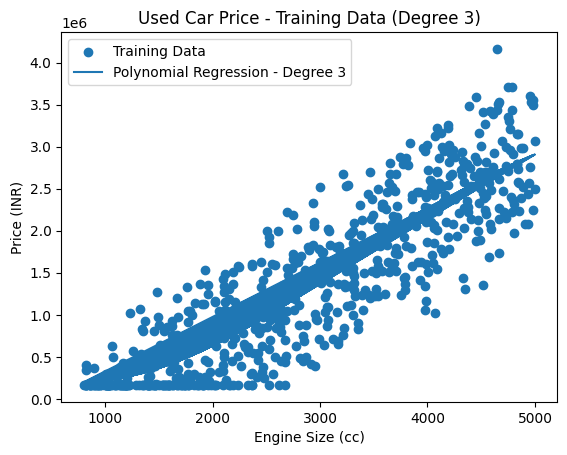

In [7]:
# Plot training data

plt.scatter(X_train, y_train, label="Training Data")

# Plot the polynomial regression curve
plt.plot(
    X_train,
    y_train_pred,
    label=f"Polynomial Regression - Degree {best_degree}"
)

plt.xlabel("Engine Size (cc)")
plt.ylabel("Price (INR)")
plt.title(f"Used Car Price - Training Data (Degree {best_degree})")
plt.legend()
plt.show()

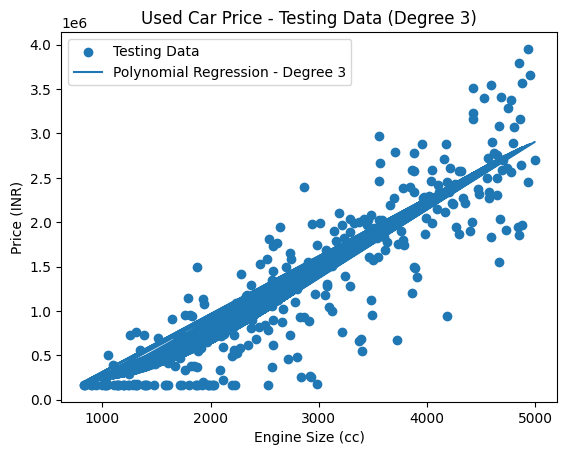

In [8]:
# Plot testing data

plt.scatter(X_test, y_test, label="Testing Data")

# Plot the polynomial regression curve
plt.plot(
    X_test,
    y_test_pred,
    label=f"Polynomial Regression - Degree {best_degree}"
)

plt.xlabel("Engine Size (cc)")
plt.ylabel("Price (INR)")
plt.title(f"Used Car Price - Testing Data (Degree {best_degree})")
plt.legend()
plt.show()

In [9]:
# Display the MSE for the best polynomial degree

print("Best Polynomial Degree:", best_degree)
print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

Best Polynomial Degree: 3
Training MSE: 199122890522.7661
Testing MSE: 197495012723.69498


## Conclusion

The dataset was divided into 70% training data and 30% testing data.

Polynomial Regression was performed using polynomial degrees from 1 to 9. The models were evaluated using Mean Squared Error (MSE).

Among all the tested polynomial degrees, **Degree 3** produced the lowest testing MSE. Therefore, Degree 3 is considered the best-performing polynomial model for predicting used car price based on engine size.